In [1]:
import pandas as pd
import re
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, GRU, Dense, Dropout
from gensim.models import Word2Vec
from sklearn.model_selection import train_test_split
from collections import Counter
from sklearn.metrics import classification_report, roc_auc_score, f1_score, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
import gensim.downloader as api
import seaborn as sns

In [2]:
# Load Dataset
file_path = "Sentiment_Data.csv"
df = pd.read_csv(file_path, encoding="ISO-8859-1")

In [3]:
df = df.groupby('Sentiment', group_keys=False).apply(lambda x: x.sample(min(len(x), 5000))).reset_index(drop=True)


C:\Users\Gurbachan\AppData\Local\Temp\ipykernel_26148\4130439342.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby('Sentiment', group_keys=False).apply(lambda x: x.sample(min(len(x), 5000))).reset_index(drop=True)


In [4]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'@\w+', '', text)  # Remove mentions
    text = re.sub(r'http\S+|www\S+', '', text)  # Remove links
    text = re.sub(r'[^a-z\s]', '', text)  # Remove special characters and numbers
    return text

df['Cleaned_Tweet'] = df['Tweet'].astype(str).apply(clean_text)

In [5]:

df_balanced = df.copy()

In [6]:
# Convert Sentiments to Three Categories
sentiment_mapping = {
    'Mild_Pos': 'Positive', 'Strong_Pos': 'Positive', 'Positive': 'Positive',
    'Mild_Neg': 'Negative', 'Strong_Neg': 'Negative', 'Negative': 'Negative',
    'Neutral': 'Neutral'
}
df_balanced['Sentiment'] = df_balanced['Sentiment'].map(sentiment_mapping)


In [7]:
# Balance Dataset
min_samples = min(Counter(df_balanced['Sentiment']).values())
df_balanced = df_balanced.groupby('Sentiment').apply(lambda x: x.sample(min_samples)).reset_index(drop=True)


C:\Users\Gurbachan\AppData\Local\Temp\ipykernel_26148\3569176332.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_balanced = df_balanced.groupby('Sentiment').apply(lambda x: x.sample(min_samples)).reset_index(drop=True)


In [8]:
# Tokenization
MAX_VOCAB_SIZE = 10000
MAX_SEQUENCE_LENGTH = 50
tokenizer = Tokenizer(num_words=MAX_VOCAB_SIZE)
tokenizer.fit_on_texts(df_balanced['Cleaned_Tweet'])
sequences = tokenizer.texts_to_sequences(df_balanced['Cleaned_Tweet'])
X = pad_sequences(sequences, maxlen=MAX_SEQUENCE_LENGTH)


In [9]:
# Encode Labels
label_mapping = {'Positive': 2, 'Negative': 0, 'Neutral': 1}
y = df_balanced['Sentiment'].map(label_mapping).values

In [10]:
# Train-Test-Validation Split (70-15-15)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42)

In [14]:
# Ensure labels remain as integer format
y_train = np.array(y_train)
y_val = np.array(y_val)

y_train = np.array(y_train)
y_val = np.array(y_val)
y_test = np.array(y_test)


In [16]:
# Handle Class Imbalance
class_weights = compute_class_weight('balanced', classes=np.unique(y_train.flatten()), y=y_train.flatten())
class_weights_dict = {i: float(class_weights[i]) for i in range(len(class_weights))}

In [17]:
# Use Pretrained FastText Embeddings
fasttext_model = api.load("fasttext-wiki-news-subwords-300")
embedding_matrix = np.zeros((MAX_VOCAB_SIZE, 300))
for word, i in tokenizer.word_index.items():
    if i < MAX_VOCAB_SIZE and word in fasttext_model:
        embedding_matrix[i] = fasttext_model[word]


In [18]:
# Build Improved Bidirectional GRU Model
model = Sequential([
    Embedding(MAX_VOCAB_SIZE, 300, weights=[embedding_matrix], trainable=False),
    Bidirectional(GRU(256, return_sequences=True, dropout=0.3, recurrent_dropout=0.3)),
    Bidirectional(GRU(128, return_sequences=False, dropout=0.3, recurrent_dropout=0.3)),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(3, activation='softmax')
])


In [19]:
# Compile Model with Label Smoothing
model.compile(loss=tf.keras.losses.SparseCategoricalCrossentropy(), 
              optimizer=tf.keras.optimizers.Adam(learning_rate=0.0003), 
              metrics=['accuracy'])

In [20]:
# Add Early Stopping
early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

In [21]:
# Train Model
if len(X_train) > 0 and len(y_train) > 0:
    history = model.fit(X_train, y_train, validation_data=(X_test, y_test), 
                        epochs=10, batch_size=32, class_weight=class_weights_dict, callbacks=[early_stopping])
else:
    print('Error: Training data is empty. Check preprocessing.')

Epoch 1/10
329/329 ━━━━━━━━━━━━━━━━━━━━ 283s 787ms/step - accuracy: 0.4147 - loss: 1.0665 - val_accuracy: 0.5329 - val_loss: 0.9484
Epoch 2/10
329/329 ━━━━━━━━━━━━━━━━━━━━ 262s 795ms/step - accuracy: 0.5355 - loss: 0.9629 - val_accuracy: 0.5649 - val_loss: 0.9230
Epoch 3/10
329/329 ━━━━━━━━━━━━━━━━━━━━ 256s 779ms/step - accuracy: 0.5548 - loss: 0.9400 - val_accuracy: 0.5924 - val_loss: 0.8933
Epoch 4/10
329/329 ━━━━━━━━━━━━━━━━━━━━ 248s 734ms/step - accuracy: 0.5621 - loss: 0.9109 - val_accuracy: 0.5964 - val_loss: 0.8789
Epoch 5/10
329/329 ━━━━━━━━━━━━━━━━━━━━ 242s 737ms/step - accuracy: 0.5778 - loss: 0.9005 - val_accuracy: 0.5898 - val_loss: 0.8802
Epoch 6/10
329/329 ━━━━━━━━━━━━━━━━━━━━ 437s 1s/step - accuracy: 0.5773 - loss: 0.8970 - val_accuracy: 0.5978 - val_loss: 0.8815
Epoch 7/10
329/329 ━━━━━━━━━━━━━━━━━━━━ 240s 728ms/step - accuracy: 0.5864 - loss: 0.8922 - val_accuracy: 0.5969 - val_loss: 0.8725
Epoch 8/10
329/329 ━━━━━━━━━━━━━━━━━━━━ 241s 730ms/step - accuracy: 0.5835 - lo

In [22]:
# Evaluate Model
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {accuracy:.4f}")

71/71 ━━━━━━━━━━━━━━━━━━━━ 10s 141ms/step - accuracy: 0.6099 - loss: 0.8397
Test Accuracy: 0.6151


In [23]:

# Generate Classification Report
y_pred = np.argmax(model.predict(X_test), axis=1)
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Negative', 'Neutral', 'Positive']))


71/71 ━━━━━━━━━━━━━━━━━━━━ 15s 170ms/step
Classification Report:
              precision    recall  f1-score   support

    Negative       0.62      0.72      0.66       773
     Neutral       0.75      0.39      0.51       741
    Positive       0.56      0.73      0.63       736

    accuracy                           0.62      2250
   macro avg       0.64      0.61      0.60      2250
weighted avg       0.64      0.62      0.60      2250



In [24]:
# Compute AUC Score
y_test_binary = tf.keras.utils.to_categorical(y_test, num_classes=3)
y_pred_probs = model.predict(X_test)
auc_score = roc_auc_score(y_test_binary, y_pred_probs, multi_class='ovr')
print(f"AUC Score: {auc_score:.4f}")

71/71 ━━━━━━━━━━━━━━━━━━━━ 10s 134ms/step
AUC Score: 0.7911


In [26]:
# Compute F1-Score
f1 = f1_score(y_test, y_pred, average='weighted')
print(f"Weighted F1-Score: {f1:.4f}")


Weighted F1-Score: 0.6048


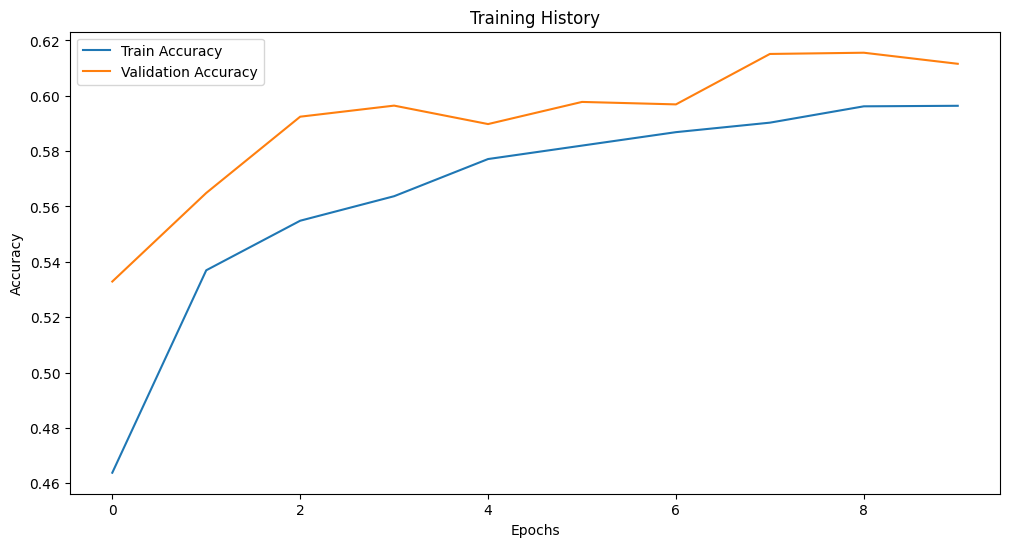

In [27]:
# Plot Training History
plt.figure(figsize=(12, 6))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training History')
plt.legend()
plt.show()